# Final Analysis

Here we plot all the results for the Alibaba test 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF
import seaborn as sns

In [2]:
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "Times"
})

In [3]:
plot_colors = {
    'cpu': '#1F4EBA',
    'gpu': '#5B8E4D',
    'memory': '#D94D47',
    'duration': '#EBC151', 
    'overall': '#AD5689'
}

In [4]:
df_features = pd.read_csv('experiments/10_000_features_rmse (11).csv', index_col=0)
df_features['Profile'] = df_features['Profile'].astype('string')

In [5]:
df_features

,Memory,GPU,CPU,Duration,Overall,Profile
0,6.449975,77.630253,62.690595,90.193966,38.517099,0
1,1.760000,13.155771,35.222222,61.924686,23.688657,0
2,5.229673,90.557573,81.374262,38.125000,17.428155,8
3,97.790837,89.964537,61.965753,96.452242,43.089896,0
4,4.756980,71.241481,57.702539,67.383513,23.710224,0
...,...,...,...,...,...,...
9995,40.689336,96.642572,90.650347,90.667380,44.287561,9
9996,4.577596,95.821064,82.496962,67.992656,32.384334,9
9997,22.211630,96.921943,84.718490,86.985193,42.420918,9
9998,28.844221,96.909605,84.716147,88.675977,43.385570,9


## ECDF Plots

### CPU Usage

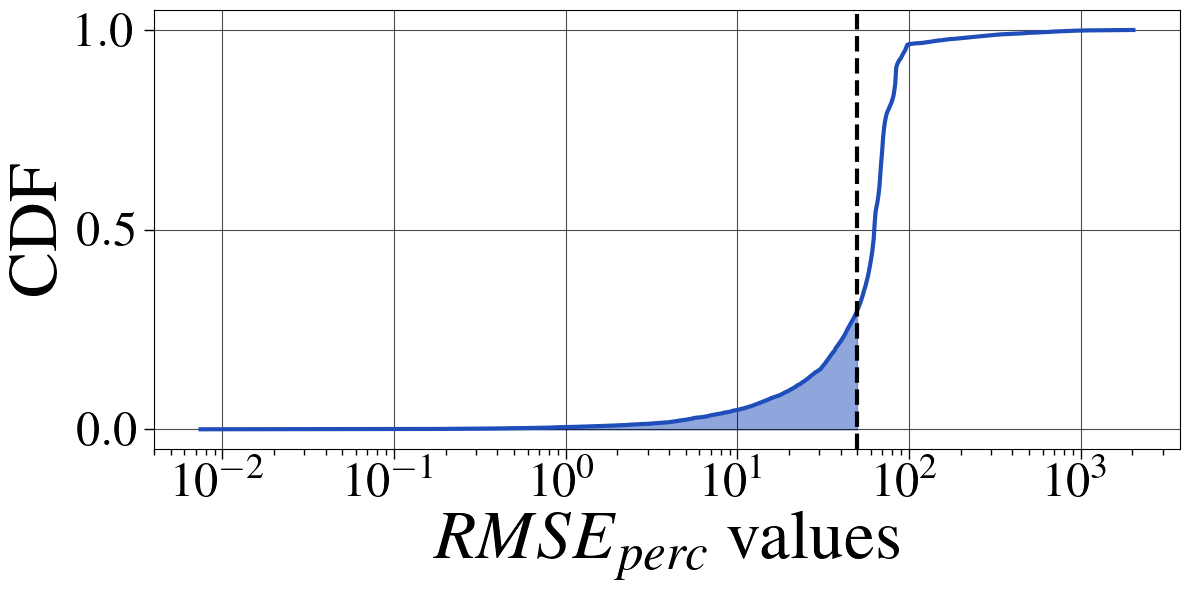

In [6]:
from statsmodels.distributions.empirical_distribution import ECDF
from matplotlib.ticker import MultipleLocator,LogLocator, NullFormatter

#plt.figure(figsize=(8, 6))  # Create a new figure for each feature
plt.subplots(figsize=(12,6))   

ecdf = ECDF(df_features['CPU'].values)

# Filter out negative or zero values from the ecdf.x data
positive_indices = ecdf.x > 0
x_positive = ecdf.x[positive_indices]
y_positive = ecdf.y[positive_indices]

# Interpolate the ECDF data on a log scale
x_new = np.logspace(np.log10(min(x_positive)), np.log10(max(x_positive)), 1000)  # Create a log space of x values
y_new = np.interp(np.log10(x_new), np.log10(x_positive), y_positive)
plt.plot(x_new, y_new, color=plot_colors['cpu'], linewidth=3)  # Plot the interpolated data

# Add a vertical line at RMSE=50
plt.axvline(x=5*10**1, color='black', linewidth=3, linestyle='--')

# Fill the area below the curve and to the left of the vertical line
plt.fill_between(x_new, y_new, where=(x_new <= 5*10**1), interpolate=True, 
                 color=plot_colors['cpu'], alpha=0.5)

# plt.title(f'ECDF of RMSE for Memory')
# plt.xlabel('RMSE')
# plt.ylabel('ECDF')


plt.grid(axis='both', which='major', color='k', alpha=0.7, linestyle='-')
plt.grid(axis='y', which='minor', color='grey', linestyle='--')

plt.xlabel(r'$RMSE_{perc}$ values', fontsize=50)
plt.ylabel(r'CDF', fontsize=50)

plt.tick_params(which='major', width=1, length=7, labelsize=35)
plt.tick_params(which='minor', width=1, length=4)


plt.xscale('log')
#plt.grid(which='both', axis='both')  # Display grid for both major and minor ticks
plt.tight_layout()

plt.savefig('Figures/TOIT_extension/CDF-test_10_000-CPU.pdf', format='pdf', bbox_inches='tight')

### Memory usage

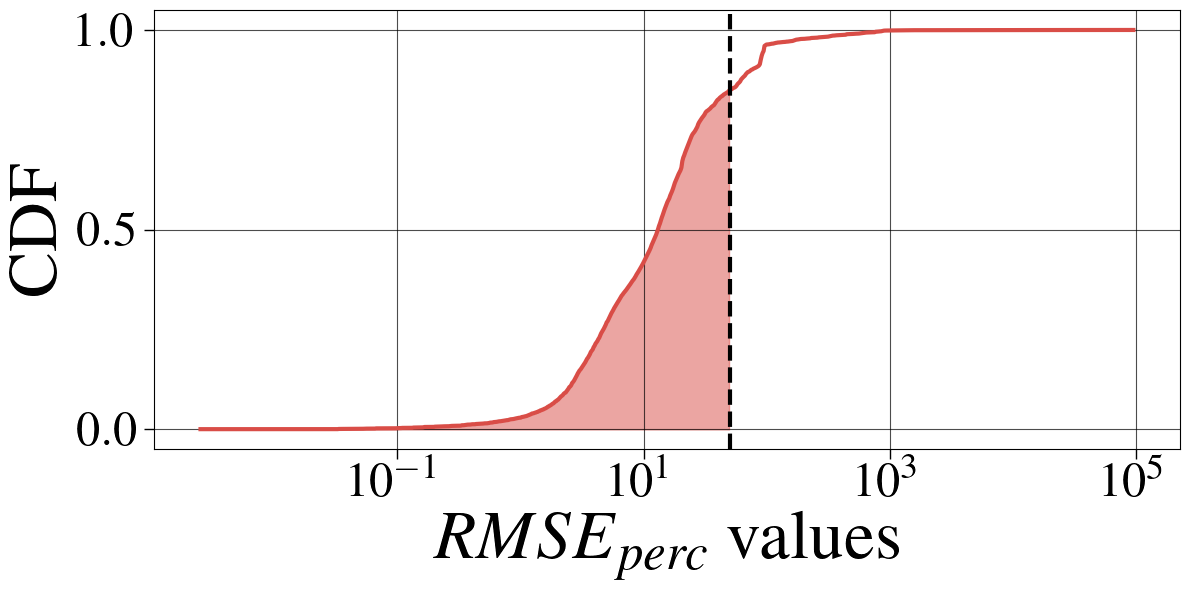

In [7]:
rmse_list = df_features['Memory'].values

plt.figure(figsize=(12, 6))  # Create a new figure for each feature

ecdf = ECDF(rmse_list)

# Filter out negative or zero values from the ecdf.x data
positive_indices = ecdf.x > 0
x_positive = ecdf.x[positive_indices]
y_positive = ecdf.y[positive_indices]

# # If no positive values are present, skip the plot for this feature
# if len(x_positive) == 0:
#     continue

# Interpolate the ECDF data on a log scale
x_new = np.logspace(np.log10(min(x_positive)), np.log10(max(x_positive)), 1000)  # Create a log space of x values
y_new = np.interp(np.log10(x_new), np.log10(x_positive), y_positive)  # Interpolate in the log space for x values

plt.plot(x_new, y_new, color=plot_colors['memory'], linewidth=3)  # Plot the interpolated data

# Add a vertical line at RMSE=50
plt.axvline(x=5*10**1, color='black', linewidth=3, linestyle='--')

# Fill the area below the curve and to the left of the vertical line
plt.fill_between(x_new, y_new, where=(x_new <= 5*10**1), interpolate=True, 
                 color=plot_colors['memory'], alpha=0.5)

plt.grid(axis='both', which='major', color='k', alpha=0.7, linestyle='-')
plt.grid(axis='y', which='minor', color='grey', linestyle='--')

plt.xlabel(r'$RMSE_{perc}$ values', fontsize=50)
plt.ylabel(r'CDF', fontsize=50)

plt.tick_params(which='major', width=1, length=7, labelsize=35)
plt.tick_params(which='minor', width=1, length=4)


plt.xscale('log')
#plt.grid(which='both', axis='both')  # Display grid for both major and minor ticks
plt.tight_layout()

plt.savefig('Figures/TOIT_extension/CDF-test_10_000-Memory.pdf', format='pdf', bbox_inches='tight')

### GPU Usage

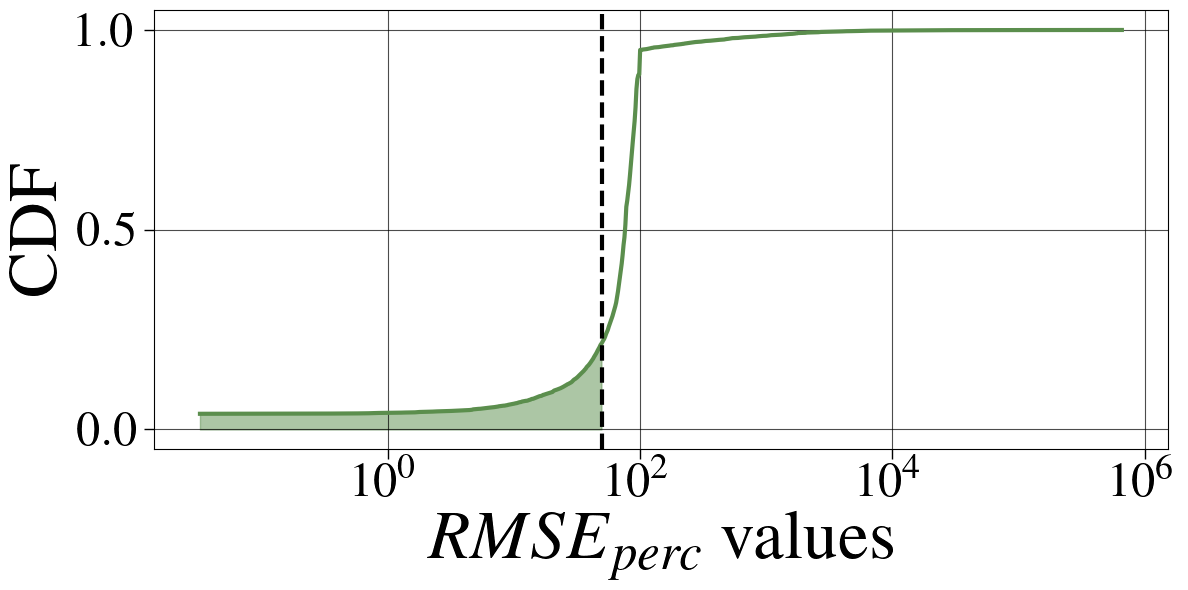

In [8]:
rmse_list = df_features['GPU'].values

plt.figure(figsize=(12, 6))  # Create a new figure for each feature

ecdf = ECDF(rmse_list)

# Filter out negative or zero values from the ecdf.x data
positive_indices = ecdf.x > 0
x_positive = ecdf.x[positive_indices]
y_positive = ecdf.y[positive_indices]

# # If no positive values are present, skip the plot for this feature
# if len(x_positive) == 0:
#     continue

# Interpolate the ECDF data on a log scale
x_new = np.logspace(np.log10(min(x_positive)), np.log10(max(x_positive)), 1000)  # Create a log space of x values
y_new = np.interp(np.log10(x_new), np.log10(x_positive), y_positive)  # Interpolate in the log space for x values

plt.plot(x_new, y_new, color=plot_colors['gpu'], linewidth=3)  # Plot the interpolated data

# Add a vertical line at RMSE=50
plt.axvline(x=5*10**1, color='black', linewidth=3, linestyle='--')

# Fill the area below the curve and to the left of the vertical line
plt.fill_between(x_new, y_new, where=(x_new <= 5*10**1), interpolate=True, 
                 color=plot_colors['gpu'], alpha=0.5)

plt.grid(axis='both', which='major', color='k', alpha=0.7, linestyle='-')
plt.grid(axis='y', which='minor', color='grey', linestyle='--')

plt.xlabel(r'$RMSE_{perc}$ values', fontsize=50)
plt.ylabel(r'CDF', fontsize=50)

plt.tick_params(which='major', width=1, length=7, labelsize=35)
plt.tick_params(which='minor', width=1, length=4)


plt.xscale('log')
#plt.grid(which='both', axis='both')  # Display grid for both major and minor ticks
plt.tight_layout()

plt.savefig('Figures/TOIT_extension/CDF-test_10_000-GPU.pdf', format='pdf', bbox_inches='tight')

### Duration 

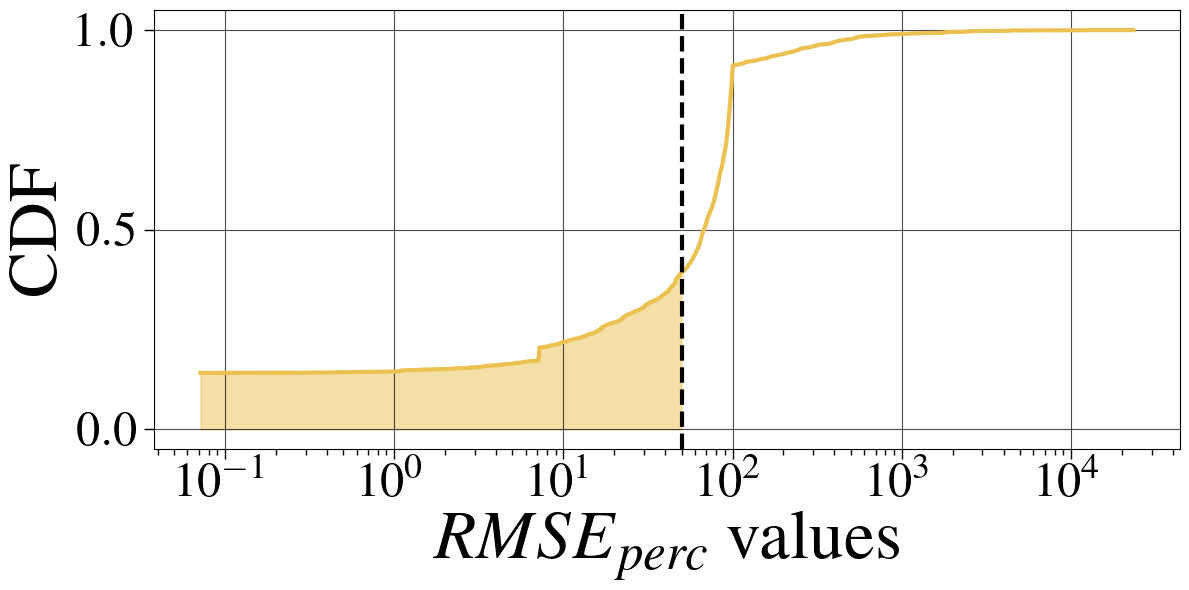

In [9]:
rmse_list = df_features['Duration'].values

plt.figure(figsize=(12, 6))  # Create a new figure for each feature

ecdf = ECDF(rmse_list)

# Filter out negative or zero values from the ecdf.x data
positive_indices = ecdf.x > 0
x_positive = ecdf.x[positive_indices]
y_positive = ecdf.y[positive_indices]

# # If no positive values are present, skip the plot for this feature
# if len(x_positive) == 0:
#     continue

# Interpolate the ECDF data on a log scale
x_new = np.logspace(np.log10(min(x_positive)), np.log10(max(x_positive)), 1000)  # Create a log space of x values
y_new = np.interp(np.log10(x_new), np.log10(x_positive), y_positive)  # Interpolate in the log space for x values

plt.plot(x_new, y_new, color=plot_colors['duration'], linewidth=3)  # Plot the interpolated data

# Add a vertical line at RMSE=50
plt.axvline(x=5*10**1, color='black', linewidth=3, linestyle='--')

# Fill the area below the curve and to the left of the vertical line
plt.fill_between(x_new, y_new, where=(x_new <= 5*10**1), interpolate=True, 
                 color=plot_colors['duration'], alpha=0.5)

plt.grid(axis='both', which='major', color='k', alpha=0.7, linestyle='-')
plt.grid(axis='y', which='minor', color='grey', linestyle='--')

plt.xlabel(r'$RMSE_{perc}$ values', fontsize=50)
plt.ylabel(r'CDF', fontsize=50)

plt.tick_params(which='major', width=1, length=7, labelsize=35)
plt.tick_params(which='minor', width=1, length=4)


plt.xscale('log')
#plt.grid(which='both', axis='both')  # Display grid for both major and minor ticks
plt.tight_layout()

plt.savefig('Figures/TOIT_extension/CDF-test_10_000-Duration.pdf', format='pdf', bbox_inches='tight')

### Overall

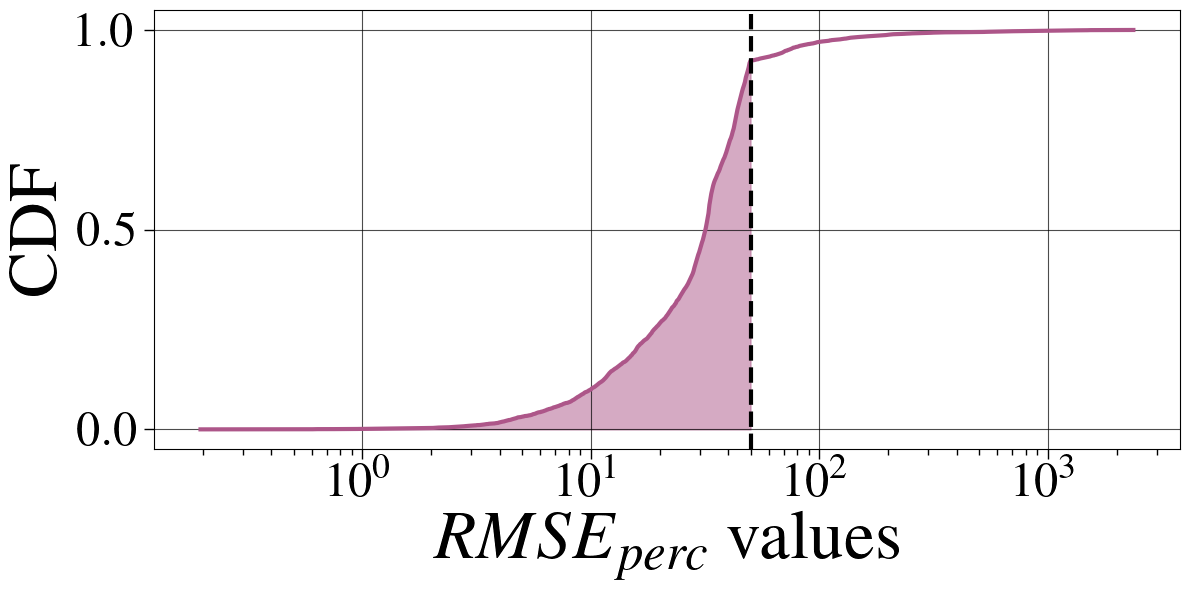

In [10]:
rmse_list = df_features['Overall'].values

plt.figure(figsize=(12, 6))  # Create a new figure for each feature

ecdf = ECDF(rmse_list)

# Filter out negative or zero values from the ecdf.x data
positive_indices = ecdf.x > 0
x_positive = ecdf.x[positive_indices]
y_positive = ecdf.y[positive_indices]

# # If no positive values are present, skip the plot for this feature
# if len(x_positive) == 0:
#     continue

# Interpolate the ECDF data on a log scale
x_new = np.logspace(np.log10(min(x_positive)), np.log10(max(x_positive)), 1000)  # Create a log space of x values
y_new = np.interp(np.log10(x_new), np.log10(x_positive), y_positive)  # Interpolate in the log space for x values

plt.plot(x_new, y_new, color=plot_colors['overall'], linewidth=3)  # Plot the interpolated data

# Add a vertical line at RMSE=50
plt.axvline(x=5*10**1, color='black', linewidth=3, linestyle='--')

# Fill the area below the curve and to the left of the vertical line
plt.fill_between(x_new, y_new, where=(x_new <= 5*10**1), interpolate=True, 
                 color=plot_colors['overall'], alpha=0.5)

plt.grid(axis='both', which='major', color='k', alpha=0.7, linestyle='-')
plt.grid(axis='y', which='minor', color='grey', linestyle='--')

plt.xlabel(r'$RMSE_{perc}$ values', fontsize=50)
plt.ylabel(r'CDF', fontsize=50)

plt.tick_params(which='major', width=1, length=7, labelsize=35)
plt.tick_params(which='minor', width=1, length=4)


plt.xscale('log')
#plt.grid(which='both', axis='both')  # Display grid for both major and minor ticks
plt.tight_layout()

plt.savefig('Figures/TOIT_extension/CDF-test_10_000-Overall.pdf', format='pdf', bbox_inches='tight')

## Profiles Boxplots

### CPU Usage

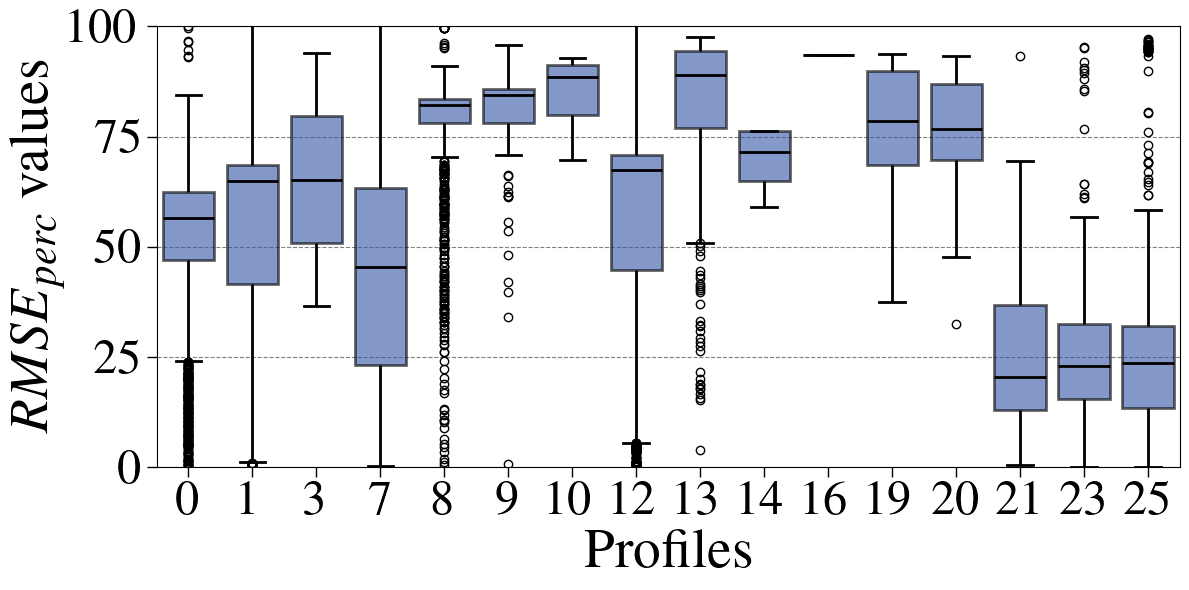

In [11]:
profiles_order = [str(x) for x in sorted(list(set(df_features['Profile'].astype(int))))]

fig, ax = plt.subplots(figsize=(12,6))



plt.axvline(100, color='red')
plt.axvline(50, color='red', linestyle='--', linewidth=2)

#plt.fill_between(range(100), [len(profiles_order)+10]*100, color='green', alpha=0.1)

sns.boxplot(y='CPU', x='Profile', data=df_features, order=profiles_order, 
            color=plot_colors['cpu'], boxprops=dict(alpha=0.6), 
            linecolor='black', linewidth=2)

# for el in df_test_rmse[df_test_rmse.rmse_perc > 100].values:
#     print(el[0], my_order.index(el[0]), el[1])
#     ax.add_patch(Ellipse((el[1], my_order.index(el[0])), 30, 1, edgecolor='red', linewidth=2, facecolor='white'))


#     ax.xaxis.set_major_locator(MultipleLocator(200))
#     ax.xaxis.set_major_formatter('{x:.0f}')
#     # For the minor ticks, use no labels; default NullFormatter.
#     ax.xaxis.set_minor_locator(MultipleLocator(100))
#     ax.xaxis.set_minor_formatter('{x:.0f}')

#     plt.grid(axis='x', which='major', color='k', alpha=0.7, linestyle='-')
#     plt.grid(axis='x', which='minor', color='grey', linestyle='--')

plt.xlabel(r'Profiles', fontsize=40)
plt.ylabel(r'$RMSE_{perc}$ values', fontsize=40)

plt.grid(axis='y', color='grey', linestyle='--')

#plt.title(r'$RMSE_{perc}$ profiles boxplot for ' + feature, fontsize=45) 

plt.ylim((0,100))
plt.tick_params(which='major', width=1, length=7, labelsize=35)
plt.tick_params(which='minor', width=1, length=4 , labelsize=25)

plt.tight_layout()

plt.savefig('Figures/TOIT_extension/Boxplot-test_10_000-CPU.pdf', format='pdf', bbox_inches='tight')

### Memory Usage

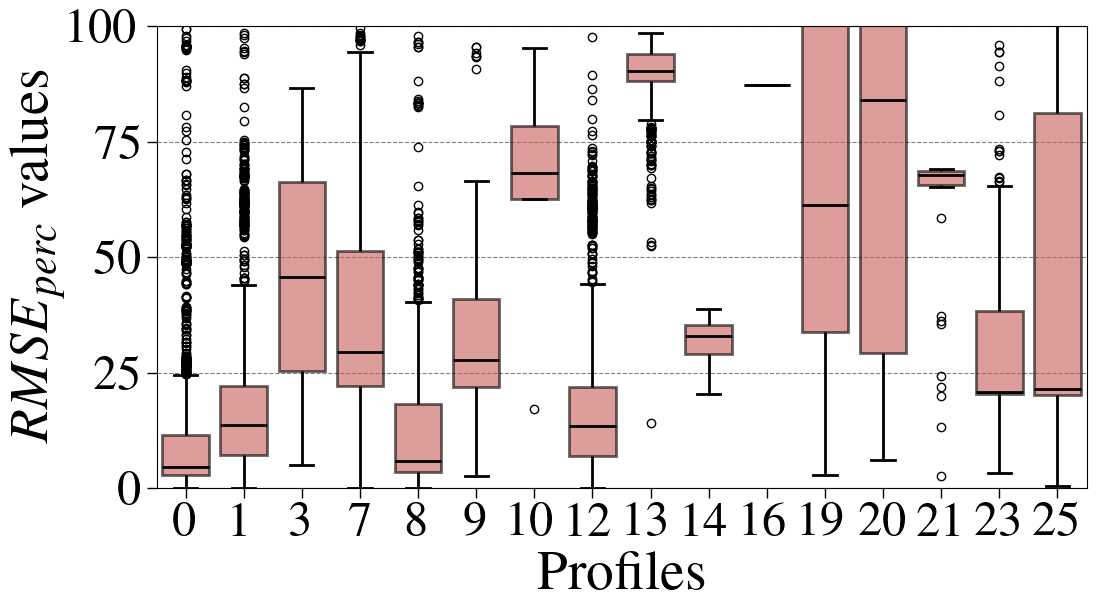

In [12]:
profiles_order = [str(x) for x in sorted(list(set(df_features['Profile'].astype(int))))]

fig, ax = plt.subplots(figsize=(12,6))



plt.axvline(100, color='red')
plt.axvline(50, color='red', linestyle='--', linewidth=2)

#plt.fill_between(range(100), [len(profiles_order)+10]*100, color='green', alpha=0.1)

sns.boxplot(y='Memory', x='Profile', data=df_features, order=profiles_order, 
            color=plot_colors['memory'], boxprops=dict(alpha=0.6), 
            linecolor='black', linewidth=2)

# for el in df_test_rmse[df_test_rmse.rmse_perc > 100].values:
#     print(el[0], my_order.index(el[0]), el[1])
#     ax.add_patch(Ellipse((el[1], my_order.index(el[0])), 30, 1, edgecolor='red', linewidth=2, facecolor='white'))


#     ax.xaxis.set_major_locator(MultipleLocator(200))
#     ax.xaxis.set_major_formatter('{x:.0f}')
#     # For the minor ticks, use no labels; default NullFormatter.
#     ax.xaxis.set_minor_locator(MultipleLocator(100))
#     ax.xaxis.set_minor_formatter('{x:.0f}')

#     plt.grid(axis='x', which='major', color='k', alpha=0.7, linestyle='-')
#     plt.grid(axis='x', which='minor', color='grey', linestyle='--')

plt.xlabel(r'Profiles', fontsize=40)
plt.ylabel(r'$RMSE_{perc}$ values', fontsize=40)

plt.grid(axis='y', color='grey', linestyle='--')

#plt.title(r'$RMSE_{perc}$ profiles boxplot for ' + feature, fontsize=45) 

plt.ylim((0,100))
plt.tick_params(which='major', width=1, length=7, labelsize=35)
plt.tick_params(which='minor', width=1, length=4 , labelsize=25)

plt.savefig('Figures/TOIT_extension/Boxplot-test_10_000-Memory.pdf', format='pdf', bbox_inches='tight')

### GPU Usage

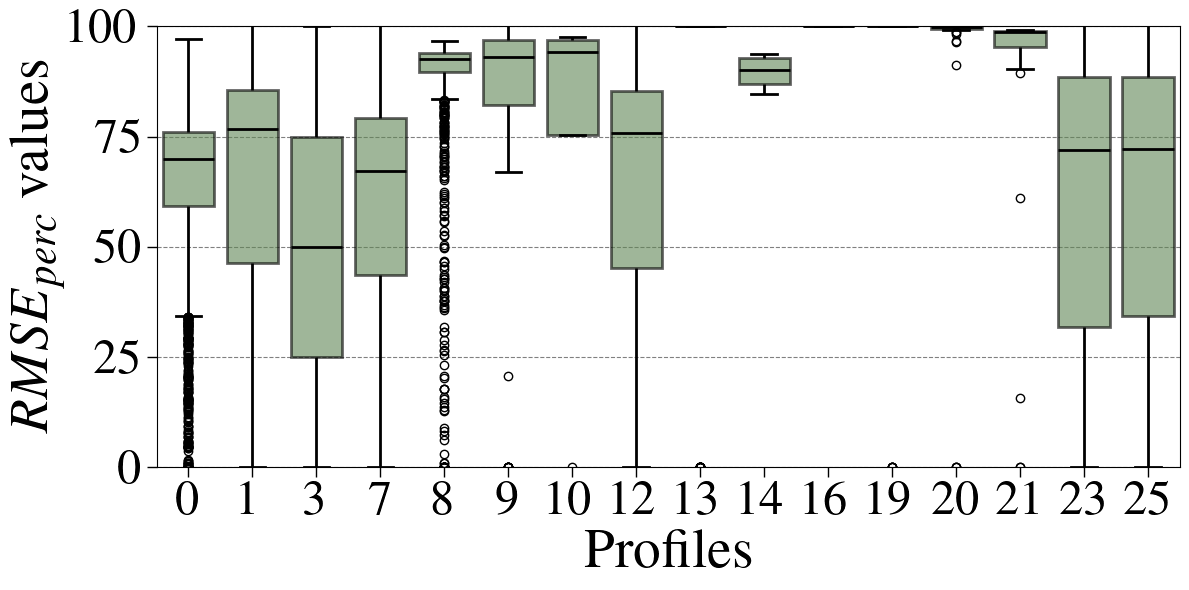

In [13]:
profiles_order = [str(x) for x in sorted(list(set(df_features['Profile'].astype(int))))]

fig, ax = plt.subplots(figsize=(12,6))



plt.axvline(100, color='red')
plt.axvline(50, color='red', linestyle='--', linewidth=2)

#plt.fill_between(range(100), [len(profiles_order)+10]*100, color='green', alpha=0.1)

sns.boxplot(y='GPU', x='Profile', data=df_features, order=profiles_order, 
            color=plot_colors['gpu'], boxprops=dict(alpha=0.6), 
            linecolor='black', linewidth=2)

# for el in df_test_rmse[df_test_rmse.rmse_perc > 100].values:
#     print(el[0], my_order.index(el[0]), el[1])
#     ax.add_patch(Ellipse((el[1], my_order.index(el[0])), 30, 1, edgecolor='red', linewidth=2, facecolor='white'))


#     ax.xaxis.set_major_locator(MultipleLocator(200))
#     ax.xaxis.set_major_formatter('{x:.0f}')
#     # For the minor ticks, use no labels; default NullFormatter.
#     ax.xaxis.set_minor_locator(MultipleLocator(100))
#     ax.xaxis.set_minor_formatter('{x:.0f}')

#     plt.grid(axis='x', which='major', color='k', alpha=0.7, linestyle='-')
#     plt.grid(axis='x', which='minor', color='grey', linestyle='--')

plt.xlabel(r'Profiles', fontsize=40)
plt.ylabel(r'$RMSE_{perc}$ values', fontsize=40)

plt.grid(axis='y', color='grey', linestyle='--')

#plt.title(r'$RMSE_{perc}$ profiles boxplot for ' + feature, fontsize=45) 

plt.ylim((0,100))
plt.tick_params(which='major', width=1, length=7, labelsize=35)
plt.tick_params(which='minor', width=1, length=4 , labelsize=25)

plt.tight_layout()

plt.savefig('Figures/TOIT_extension/Boxplot-test_10_000-GPU.pdf', format='pdf', bbox_inches='tight')

### Duration

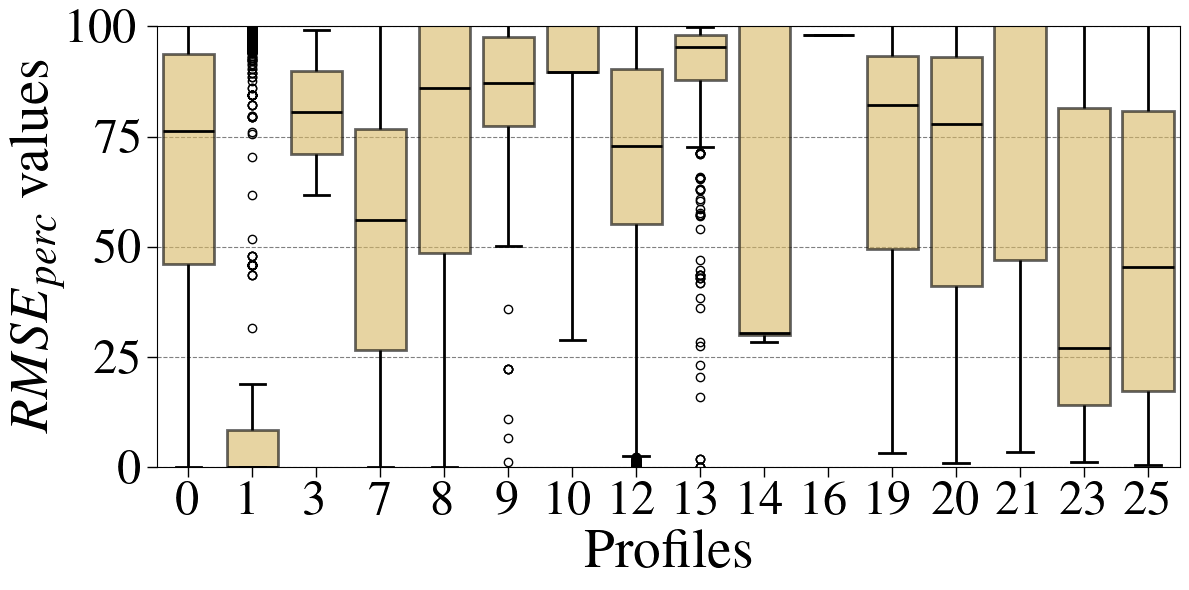

In [14]:
profiles_order = [str(x) for x in sorted(list(set(df_features['Profile'].astype(int))))]

fig, ax = plt.subplots(figsize=(12,6))



plt.axvline(100, color='red')
plt.axvline(50, color='red', linestyle='--', linewidth=2)

#plt.fill_between(range(100), [len(profiles_order)+10]*100, color='green', alpha=0.1)

sns.boxplot(y='Duration', x='Profile', data=df_features, order=profiles_order, 
            color=plot_colors['duration'], boxprops=dict(alpha=0.6), 
            linecolor='black', linewidth=2)

# for el in df_test_rmse[df_test_rmse.rmse_perc > 100].values:
#     print(el[0], my_order.index(el[0]), el[1])
#     ax.add_patch(Ellipse((el[1], my_order.index(el[0])), 30, 1, edgecolor='red', linewidth=2, facecolor='white'))


#     ax.xaxis.set_major_locator(MultipleLocator(200))
#     ax.xaxis.set_major_formatter('{x:.0f}')
#     # For the minor ticks, use no labels; default NullFormatter.
#     ax.xaxis.set_minor_locator(MultipleLocator(100))
#     ax.xaxis.set_minor_formatter('{x:.0f}')

#     plt.grid(axis='x', which='major', color='k', alpha=0.7, linestyle='-')
#     plt.grid(axis='x', which='minor', color='grey', linestyle='--')

plt.xlabel(r'Profiles', fontsize=40)
plt.ylabel(r'$RMSE_{perc}$ values', fontsize=40)

plt.grid(axis='y', color='grey', linestyle='--')

#plt.title(r'$RMSE_{perc}$ profiles boxplot for ' + feature, fontsize=45) 

plt.ylim((0,100))
plt.tick_params(which='major', width=1, length=7, labelsize=35)
plt.tick_params(which='minor', width=1, length=4 , labelsize=25)

plt.tight_layout()

plt.savefig('Figures/TOIT_extension/Boxplot-test_10_000-Duration.pdf', format='pdf', bbox_inches='tight')

### Overall

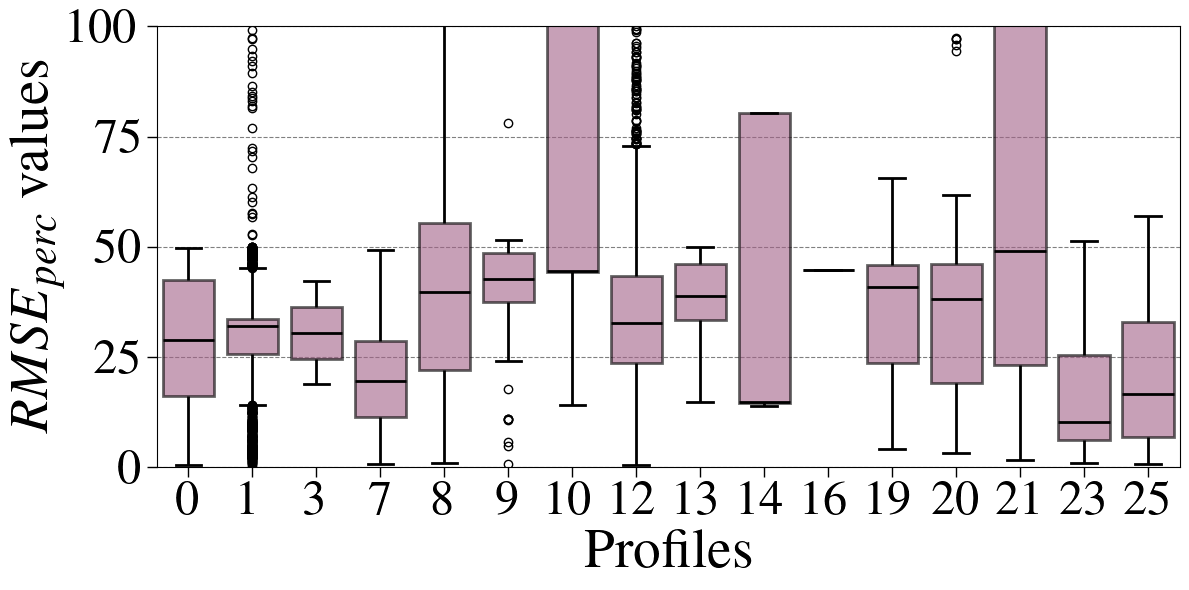

In [15]:
profiles_order = [str(x) for x in sorted(list(set(df_features['Profile'].astype(int))))]

fig, ax = plt.subplots(figsize=(12,6))



plt.axvline(100, color='red')
plt.axvline(50, color='red', linestyle='--', linewidth=2)

#plt.fill_between(range(100), [len(profiles_order)+10]*100, color='green', alpha=0.1)

sns.boxplot(y='Overall', x='Profile', data=df_features, order=profiles_order, 
            color=plot_colors['overall'], boxprops=dict(alpha=0.6), 
            linecolor='black', linewidth=2)

# for el in df_test_rmse[df_test_rmse.rmse_perc > 100].values:
#     print(el[0], my_order.index(el[0]), el[1])
#     ax.add_patch(Ellipse((el[1], my_order.index(el[0])), 30, 1, edgecolor='red', linewidth=2, facecolor='white'))


#     ax.xaxis.set_major_locator(MultipleLocator(200))
#     ax.xaxis.set_major_formatter('{x:.0f}')
#     # For the minor ticks, use no labels; default NullFormatter.
#     ax.xaxis.set_minor_locator(MultipleLocator(100))
#     ax.xaxis.set_minor_formatter('{x:.0f}')

#     plt.grid(axis='x', which='major', color='k', alpha=0.7, linestyle='-')
#     plt.grid(axis='x', which='minor', color='grey', linestyle='--')

plt.xlabel(r'Profiles', fontsize=40)
plt.ylabel(r'$RMSE_{perc}$ values', fontsize=40)

plt.grid(axis='y', color='grey', linestyle='--')

#plt.title(r'$RMSE_{perc}$ profiles boxplot for ' + feature, fontsize=45) 

plt.ylim((0,100))
plt.tick_params(which='major', width=1, length=7, labelsize=35)
plt.tick_params(which='minor', width=1, length=4 , labelsize=25)

plt.tight_layout()

plt.savefig('Figures/TOIT_extension/Boxplot-test_10_000-Overall.pdf', format='pdf', bbox_inches='tight')